<a href="https://colab.research.google.com/github/lucasvazelle/nexialog_challlenge/blob/main/etape4_model_sans_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [272]:
! pip install ace-tools

In [274]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# from scipy.stats import genpareto


In [4]:
# chemin
file_path = "/content/drive/MyDrive/nexialog/data_agrege_S3.parquet"

# Lire le fichier Parquet
data_agrege_S3 = pd.read_parquet(file_path)


In [10]:
data_agrege_S3.columns

Index(['olt_name', 'date_hour', 'code_departement', 'olt_model', 'peag_nro',
       'boucle', 'dsp', 'pop_dns', 'nb_test_dns', 'avg_dns_time',
       'std_dns_time', 'nb_test_scoring', 'avg_latence_scoring',
       'std_latence_scoring', 'avg_score_scoring', 'std_score_scoring',
       'nb_client_total', 'moment_journee', 'depts_egaux', 'meme_region',
       'missing_avg_dns_time', 'missing_std_dns_time',
       'missing_avg_latence_scoring', 'missing_std_latence_scoring',
       'missing_avg_score_scoring', 'missing_std_score_scoring', 'type_boucle',
       'type_olt_model', 'encodage_heure_sin', 'encodage_heure_cos',
       'encodage_jour_semaine_sin', 'encodage_jour_semaine_cos', 'week_end'],
      dtype='object')

In [17]:

distinct_olt_names = data_agrege_S3['olt_name'].unique()

# Afficher les valeurs distinctes
distinct_olt_names


array(['01_olt_1', '01_olt_10', '01_olt_11', ..., '95_olt_5629',
       '95_olt_5630', '95_olt_5631'], dtype=object)

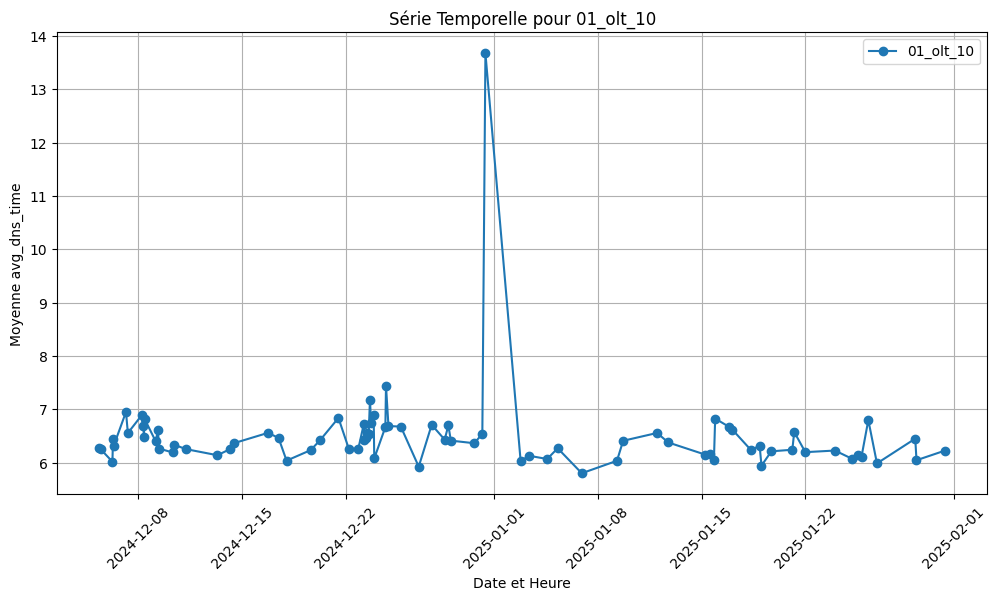

In [29]:
olt_name = "01_olt_10"  # Remplace par le nom de l'OLT souhaité
df_olt = data_agrege_S3[data_agrege_S3["olt_name"] == olt_name]

plt.figure(figsize=(12, 6))
plt.plot(olt_1["date_hour"], olt_1["avg_dns_time"], marker="o", linestyle="-", label=olt_a_visualiser)
plt.xlabel("Date et Heure")
plt.ylabel("Moyenne avg_dns_time")
plt.title(f"Série Temporelle pour {olt_a_visualiser}")
plt.xticks(rotation=45)
plt.legend()
plt.grid()
plt.show()


# Jump classique Andersel et Al

In [255]:
def detect_jumps_andersen(df, window=50, lambda_quantile=0.99999):
    """
    Détecte les jumps en utilisant la méthode d'Andersen, Bollerslev et Dobrev (2007).
    - window : taille de la fenêtre pour la volatilité locale. Petit window (ex: 5-10) → Détection rapide mais risque de faux positifs.
                                                               Grand window (ex: 20-50) → Filtre mieux le bruit mais peut rater des petits jumps.
    - lambda_quantile : quantile de la loi normale pour fixer le seuil. Seuil faible (ex: 0.95, Q=1.64) → Détecte plus de jumps, mais risque de bruit.
                                                                        Seuil élevé (ex: 0.99, Q=2.33 ou 0.999, Q=3.09) → Plus strict, détecte seulement des gros jumps.
    """
    df = df.copy()
    df["log_dns"] = np.log(df["avg_dns_time"])  # Log pour mieux capturer les variations relatives
    df["diff_log"] = df["log_dns"].diff()  # Différence logarithmique pour mesurer les variations

    # Estimation de la volatilité locale (rolling std des différences log)
    df["volatility"] = df["diff_log"].rolling(window=window, min_periods=1).std()

    # Calcul de la statistique de test normalisée
    df["stat_jump"] = df["diff_log"] / df["volatility"]

    # Seuil basé sur le quantile de la loi normale standard
    jump_threshold = stats.norm.ppf(lambda_quantile)  # Exemple : pour 0.99 -> seuil ≈ 2.33
    df["is_jump"] = df["stat_jump"] > jump_threshold

    return df


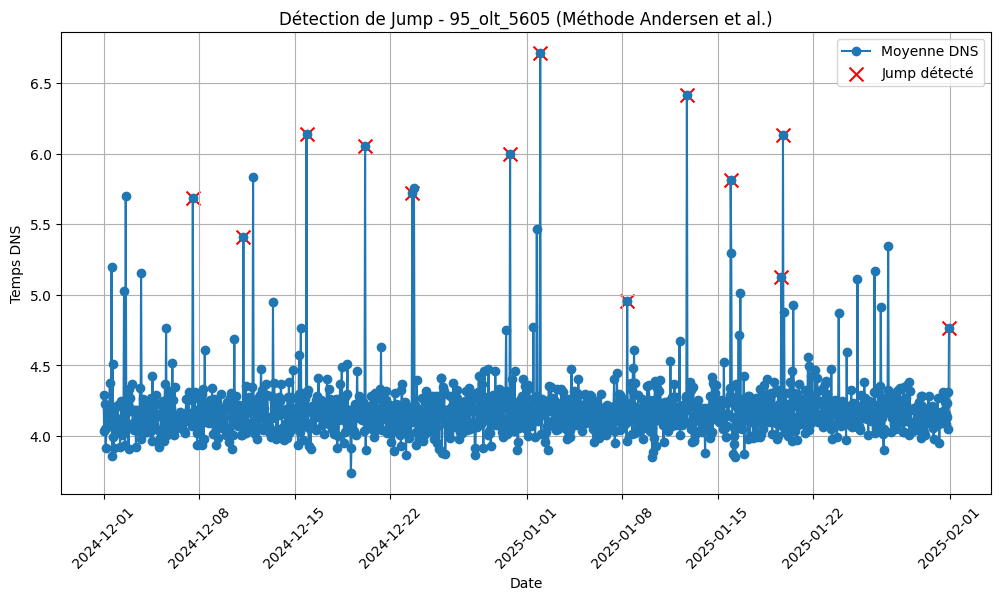

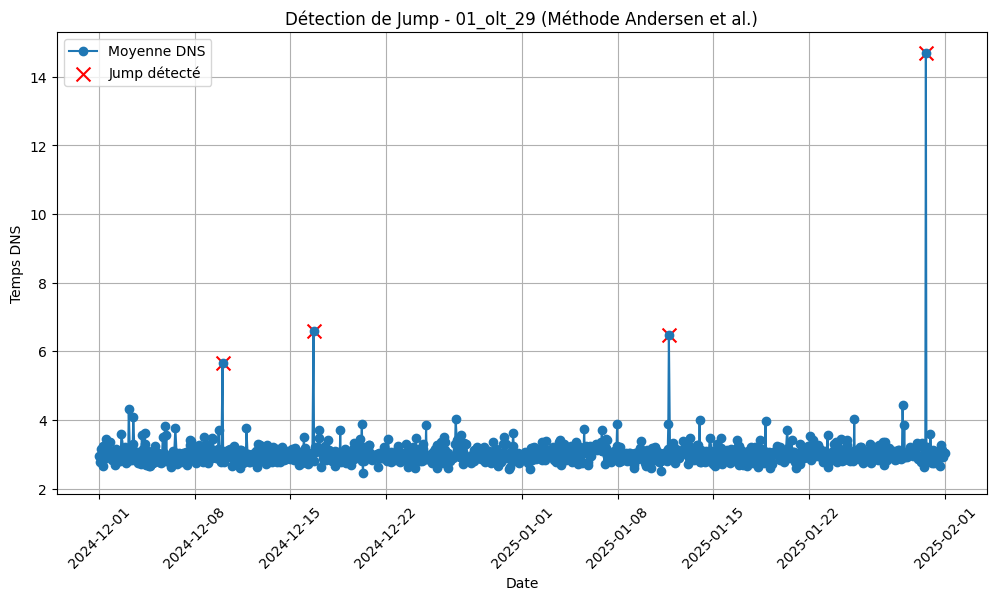

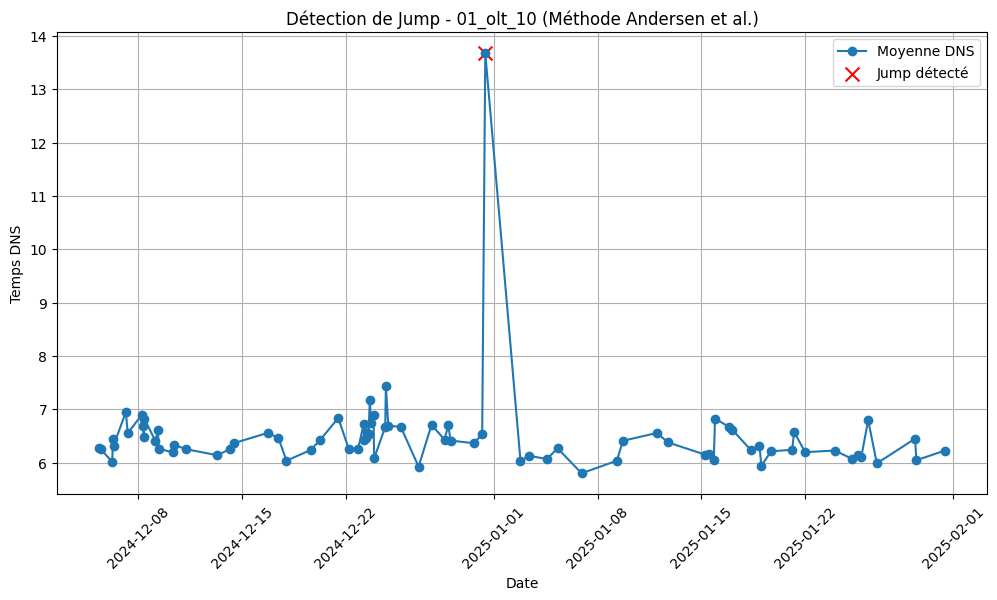

In [297]:
olt_name_list = ["95_olt_5605", "01_olt_29", "01_olt_10" ] # Remplace par le nom de l'OLT souhaité
for olt_name in olt_name_list:
  df_olt = data_agrege_S3[data_agrege_S3["olt_name"] == olt_name]

  # Appliquer la détection de jumps
  df_jumps = detect_jumps_andersen(df_olt)

  # Tracer les résultats
  plt.figure(figsize=(12, 6))
  plt.plot(df_olt["date_hour"], df_olt["avg_dns_time"], label="Moyenne DNS", marker="o", linestyle="-")
  plt.scatter(df_jumps[df_jumps["is_jump"]]["date_hour"], df_jumps[df_jumps["is_jump"]]["avg_dns_time"],
              color="red", label="Jump détecté", marker="x", s=100)
  plt.xlabel("Date")
  plt.ylabel("Temps DNS")
  plt.title(f"Détection de Jump - {olt_name} (Méthode Andersen et al.)")
  plt.legend()
  plt.xticks(rotation=45)
  plt.grid()
  plt.show()


In [258]:
# Définir un seuil minimum d'observations par OLT
SEUIL_MIN_OBSERVATIONS = 50  # Ajuste ce seuil selon tes besoins

# Compter le nombre d'observations par OLT
olt_counts = data_agrege_S3["olt_name"].value_counts()

# Filtrer les OLTs qui ont suffisamment d'observations
olt_filtrés = olt_counts[olt_counts >= SEUIL_MIN_OBSERVATIONS].index

# Afficher le nombre d'OLTs retenus après filtrage
print(f"📊 Nombre d'OLTs retenus après filtrage des olt qui n'ont pas assez d'observations: {len(olt_filtrés)} / {len(olt_counts)}")

# Stocker les résultats de chaque OLT
df_jumps_all = []

# Itérer sur chaque OLT sélectionné et appliquer la détection
for olt in olt_filtrés:
    df_olt = data_agrege_S3[data_agrege_S3["olt_name"] == olt].sort_values("date_hour")
    df_jumps = detect_jumps_andersen(df_olt)  # Appliquer la détection de jumps
    df_jumps["olt_name"] = olt  # Ajouter la colonne OLT
    df_jumps_all.append(df_jumps)


📊 Nombre d'OLTs retenus après filtrage des olt qui n'ont pas assez d'observations: 3834 / 5296


In [301]:
# Concaténer toutes les tables
df_jumps_final = pd.concat(df_jumps_all, ignore_index=True)


In [302]:
output_path = "/content/drive/MyDrive/nexialog/data_with_anomalies_with_jump_model.csv"


# Exporter le DataFrame au format CSV
df_jumps_final.to_csv(output_path, index=False, encoding='utf-8')

print(f"Fichier exporté avec succès à : {output_path}")


Fichier exporté avec succès à : /content/drive/MyDrive/nexialog/data_with_anomalies_with_jump_model.csv


🔴 Nombre total de jumps détectés : 18121
📊 Proportion de jumps par OLT : 3.42
📊 Proportion de jumps par jours : 302.02


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


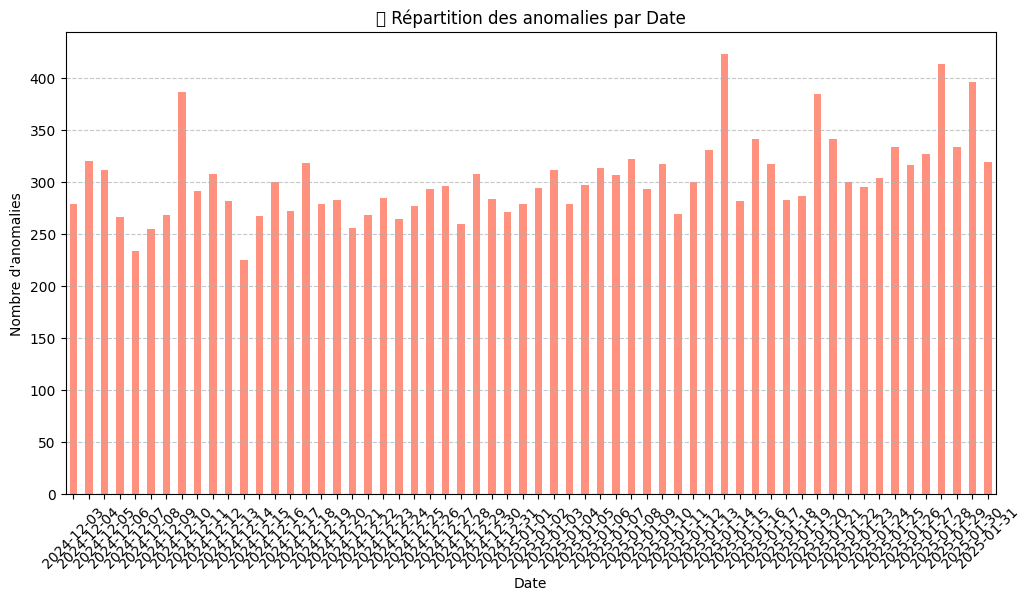

In [265]:

# Concaténer toutes les tables
df_jumps_final = pd.concat(df_jumps_all, ignore_index=True)

start_date = df_jumps_final["date_hour"].min().normalize()  # début des données
cutoff_date = start_date + pd.Timedelta(days=2)  # limite des deux premiers jours
df_jumps_final = df_jumps_final[df_jumps_final["date_hour"] > cutoff_date]

# Nombre total de jumps détectés
total_jumps = df_jumps_final["is_jump"].sum()
print(f"🔴 Nombre total de jumps détectés : {total_jumps}")

# Proportion de jumps par rapport au nombre d'OLTs
jump_ratio = total_jumps / len(olt_list)
print(f"📊 Proportion de jumps par OLT : {jump_ratio:.2f}")


# Proportion de jumps par rapport au nombre d'OLTs
jump_ratio_par_j = total_jumps / 60
print(f"📊 Proportion de jumps par jours : {jump_ratio_par_j:.2f}")

# Répartition des jumps par date
jump_dates = df_jumps_final[df_jumps_final["is_jump"]]["date_hour"].dt.date.value_counts().sort_index()

# Affichage de la répartition des dates
plt.figure(figsize=(12, 6))
jump_dates.plot(kind="bar", color="tomato", alpha=0.7)
plt.xlabel("Date")
plt.ylabel("Nombre d'anomalies")
plt.title("📅 Répartition des anomalies par Date")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


In [295]:
df_jumps_final[df_jumps_final["is_jump"]==1].head()

,olt_name,date_hour,code_departement,olt_model,peag_nro,boucle,dsp,pop_dns,nb_test_dns,avg_dns_time,...,encodage_heure_sin,encodage_heure_cos,encodage_jour_semaine_sin,encodage_jour_semaine_cos,week_end,log_dns,diff_log,volatility,stat_jump,is_jump
68,95_olt_5606,2024-12-03 20:00:00,95,old0,78_peag_2918,BU22,dsp_1,94_cbv,113,4.577369,...,-0.866025,0.500000,0.781831,0.623490,False,1.521124,0.301125,0.062109,4.848357,True
395,95_olt_5606,2024-12-17 11:00:00,95,old0,78_peag_2918,BU22,dsp_1,94_cbv,71,5.926437,...,0.258819,-0.965926,0.781831,0.623490,False,1.779423,0.523086,0.088849,5.887339,True
487,95_olt_5606,2024-12-21 07:00:00,95,old0,78_peag_2918,BU22,dsp_1,94_cbv,222,5.132649,...,0.965926,-0.258819,-0.974928,-0.222521,True,1.635622,0.448374,0.079964,5.607188,True
566,95_olt_5606,2024-12-24 14:00:00,95,old0,78_peag_2918,BU22,dsp_1,94_cbv,109,5.084553,...,-0.500000,-0.866025,0.781831,0.623490,False,1.626207,0.422935,0.085579,4.942061,True
720,95_olt_5606,2024-12-31 00:00:00,95,old0,78_peag_2918,BU22,dsp_1,94_cbv,200,6.833655,...,0.000000,1.000000,0.781831,0.623490,False,1.921860,0.717407,0.114301,6.276497,True


In [303]:
# Sélection des colonnes utiles
features = ['type_boucle', 'type_olt_model', 'week_end', 'is_jump']

# Grouper par les variables et compter les jumps
df_summary = df_jumps_final[features].groupby(
    ['type_boucle', 'type_olt_model', 'week_end']
).agg(
    total=('is_jump', 'count'),
    jumps=('is_jump', 'sum')
).reset_index()

# Ajouter une colonne pour le pourcentage de jumps
df_summary["jump_rate"] = df_summary["jumps"] / df_summary["total"]


In [304]:
df_summary[df_summary["jumps"]!=0]

,type_boucle,type_olt_model,week_end,total,jumps,jump_rate
0,BU,New,False,1559018,8087,0.005187
1,BU,New,True,590542,2649,0.004486
2,BU,old,False,344908,1583,0.004590
3,BU,old,True,130483,494,0.003786
4,FTTH,New,False,869571,4234,0.004869
5,FTTH,New,True,330612,1394,0.004216
6,FTTH,old,False,10471,54,0.005157
7,FTTH,old,True,3953,17,0.004301


Ouput :
Tableau en fonction seuil le nombre de jump détecté

Lister les avantages du jump : indépendant du modèle, région etc.. on prends en compte spécifité du réseau

Abre séparant le total des jump en fonction du modèle, région et date clés

# Modéliser l'apparition des jumps DNS avec le processus de Hawkes Non retenu et impossible sur collab d'avoir tick

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tick.hawkes import HawkesExpKern

# Charger les données (on suppose que df_jumps_final contient les jumps détectés)
df_jumps = df_jumps_final[df_jumps_final["is_jump"]]  # Garder uniquement les jumps
df_jumps = df_jumps.sort_values("date_hour")  # Trier par date

# Convertir les timestamps en format numérique (secondes depuis le début)
t_start = df_jumps["date_hour"].min()
timestamps = (df_jumps["date_hour"] - t_start).dt.total_seconds().values

# Préparer les timestamps sous forme de liste (format pour tick)
timestamps_list = [timestamps]

# Initialiser et ajuster le modèle de Hawkes avec un noyau exponentiel
hawkes = HawkesExpKern(decay=0.1)  # decay définit la décroissance de l'excitation
hawkes.fit(timestamps_list)

# Récupérer les paramètres estimés
mu_est, alpha_est = hawkes.baseline[0], hawkes.adjacency[0, 0]

# Afficher les résultats
print(f"📊 Intensité de base (μ) : {mu_est:.4f}")
print(f"🔥 Auto-excitation (α) : {alpha_est:.4f}")

# Visualisation des timestamps et intensité du processus
plt.figure(figsize=(12, 5))
plt.hist(timestamps, bins=50, color="blue", alpha=0.7, label="Jumps détectés")
plt.xlabel("Temps (secondes depuis début)")
plt.ylabel("Nombre de jumps")
plt.title("📈 Répartition des Jumps DNS dans le temps")
plt.legend()
plt.grid()
plt.show()


<ipython-input-299-6e62c0949c4f>:11: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_jumps["date"] = df_jumps["date_hour"].dt.floor("H")  # Regrouper à l’heure
<ipython-input-299-6e62c0949c4f>:14: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  time_range = pd.date_range(df_jumps["date"].min(), df_jumps["date"].max(), freq="H")


<Figure size 1200x500 with 0 Axes>

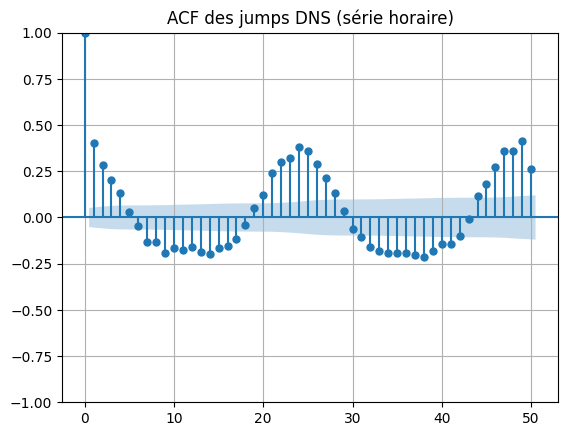

In [299]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf

# --- Étape 1 : série binaire des jumps par heure/jour ---

# On suppose que df_jumps_final existe déjà
df_jumps = df_jumps_final[df_jumps_final["is_jump"]].copy()
df_jumps["date"] = df_jumps["date_hour"].dt.floor("H")  # Regrouper à l’heure

# Créer une série temporelle binaire : 1 si jump, 0 sinon
time_range = pd.date_range(df_jumps["date"].min(), df_jumps["date"].max(), freq="H")
jump_series = pd.Series(0, index=time_range)
jump_counts = df_jumps["date"].value_counts()
jump_series[jump_counts.index] = jump_counts.values

# --- Étape 2 : ACF (autocorrelation) ---

plt.figure(figsize=(12, 5))
plot_acf(jump_series, lags=50, title="ACF des jumps DNS (série horaire)")
plt.grid()
plt.show()


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


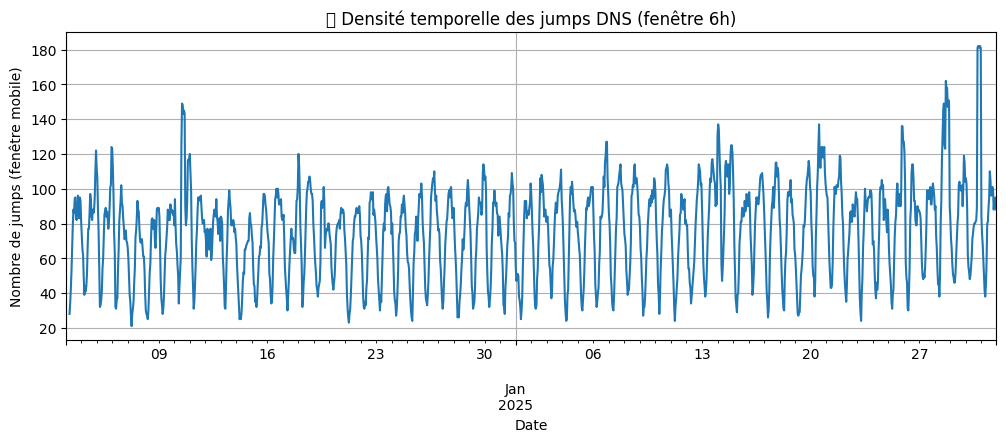

In [300]:
plt.figure(figsize=(12, 4))
jump_series.rolling(window=6).sum().plot()
plt.title("🔍 Densité temporelle des jumps DNS (fenêtre 6h)")
plt.xlabel("Date")
plt.ylabel("Nombre de jumps (fenêtre mobile)")
plt.grid()
plt.show()


# Jump utilisant la théorie des valeurs extrêmes (Andersen et Al.) NON RETENU

In [110]:
def detect_jumps_evt(df, window=2, lambda_quantile=0.999):
    df = df.copy()
    df["log_dns"] = np.log(df["avg_dns_time"])  # Transformation log pour éviter les effets de scale
    df["diff_log"] = df["log_dns"].diff()  # Différence log pour capturer les variations relatives

    # Estimation de la volatilité locale
    df["volatility"] = df["diff_log"].rolling(window=window, min_periods=1).std()

    # Calcul de la statistique de test normalisée
    df["stat_jump"] = df["diff_log"].abs() / df["volatility"]

    # Extraction des valeurs extrêmes pour la modélisation EVT
    extreme_values = df["stat_jump"].dropna()
    threshold = np.percentile(extreme_values, 95)  # Seuil initial pour EVT (top 5%)

    # Ajustement de la Generalized Pareto Distribution (GPD)
    params = genpareto.fit(extreme_values[extreme_values > threshold])
    xi, mu, sigma = params

    # Calcul du seuil EVT
    evt_threshold = mu + (sigma / xi) * ((1 / (1 - lambda_quantile)) ** (-xi) - 1)

    # Détection des jumps
    df["is_jump"] = df["stat_jump"] > evt_threshold

    return df, evt_threshold

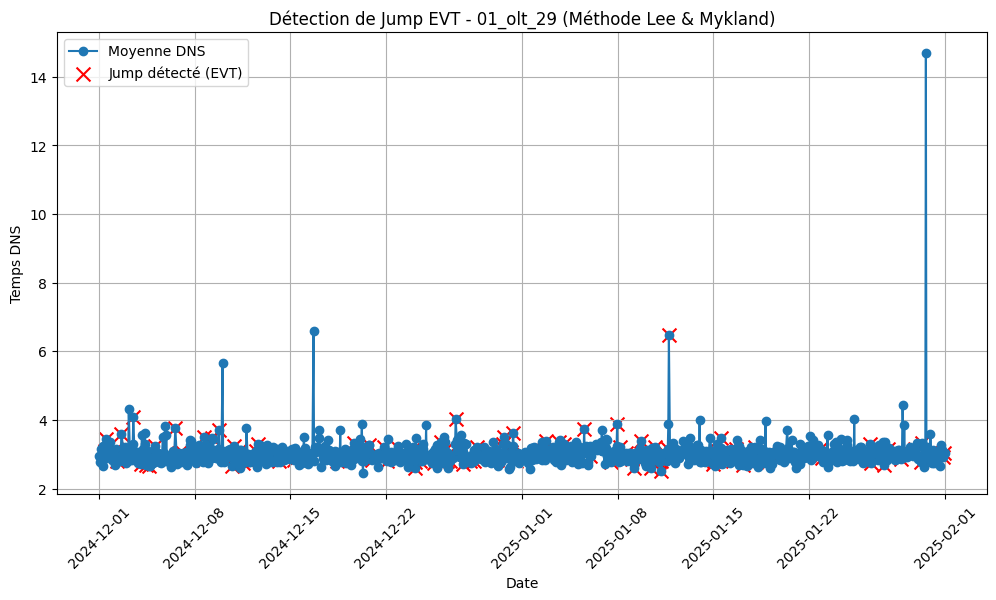

🔴 Seuil EVT calculé : 2.24
📊 Nombre total de jumps détectés : 140


In [111]:
olt_name = "01_olt_29"  # Remplace par l'OLT souhaité
df_olt = data_agrege_S3[data_agrege_S3["olt_name"] == olt_name].sort_values("date_hour")

# Appliquer la détection EVT
df_jumps, evt_threshold = detect_jumps_evt(df_olt)

# Tracer les résultats
plt.figure(figsize=(12, 6))
plt.plot(df_olt["date_hour"], df_olt["avg_dns_time"], label="Moyenne DNS", marker="o", linestyle="-")
plt.scatter(df_jumps[df_jumps["is_jump"]]["date_hour"], df_jumps[df_jumps["is_jump"]]["avg_dns_time"],
            color="red", label="Jump détecté (EVT)", marker="x", s=100)
plt.xlabel("Date")
plt.ylabel("Temps DNS")
plt.title(f"Détection de Jump EVT - {olt_name} (Méthode Lee & Mykland)")
plt.legend()
plt.xticks(rotation=45)
plt.grid()
plt.show()

# Affichage du seuil EVT et nombre de jumps détectés
print(f"🔴 Seuil EVT calculé : {evt_threshold:.2f}")
print(f"📊 Nombre total de jumps détectés : {df_jumps['is_jump'].sum()}")